<a href="https://colab.research.google.com/github/EmilKarimov3/Emil_INFO4670_Fall2026/blob/main/Assignment3_AssociationRuleMining_Emil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (9465 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [10]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module=r"jupyter_client\.session"
)

%pip install -q pandas matplotlib mlxtend networkx

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.frequent_patterns import fpgrowth, association_rules

bread = pd.read_csv("/content/bread_basket-2.csv")

print("Rows:", len(bread))
print("Unique transactions:", bread["transaction"].nunique())
print(bread.head().to_string(index=False))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Rows: 20507
Unique transactions: 9465
 transaction          item  date_time  time period_day weekday_weekend
           1         Bread 30/10/2016  9:58    morning         weekend
           2  Scandinavian 30/10/2016 10:05    morning         weekend
           2  Scandinavian 30/10/2016 10:05    morning         weekend
           3 Hot chocolate 30/10/2016 10:07    morning         weekend
           3           Jam 30/10/2016 10:07    morning         weekend


## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [11]:
print(bread.dtypes.to_string())

transaction         int64
item               object
date_time          object
time               object
period_day         object
weekday_weekend    object


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for Statistics.

In [12]:
display(bread.describe(include="all"))

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**.

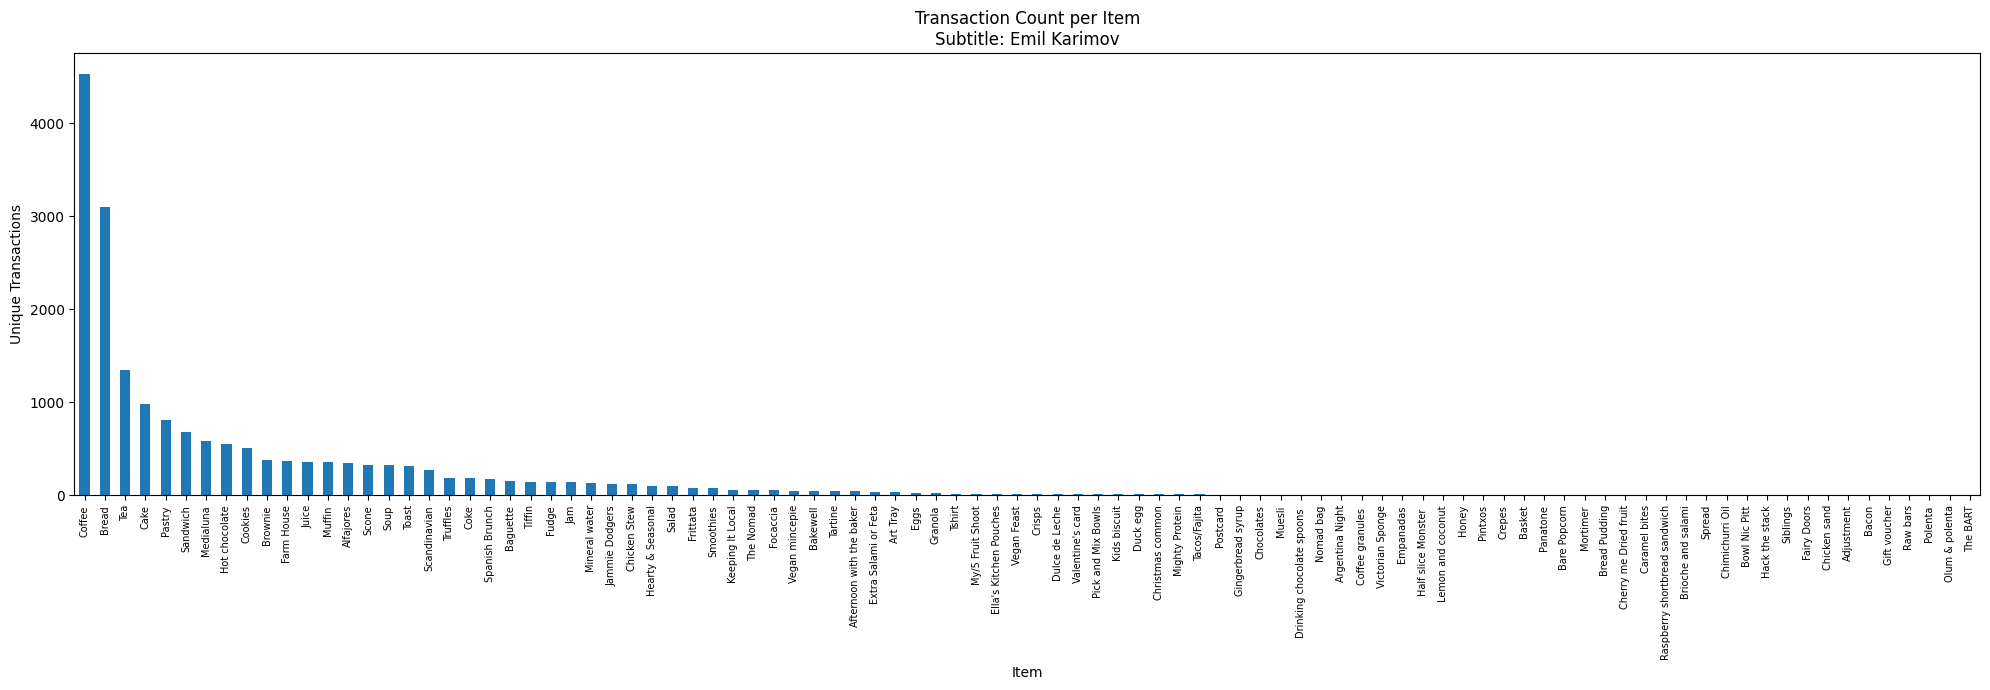

In [13]:
subtitle = "Emil Karimov"

item_counts = (
    bread.groupby("item")["transaction"]
    .nunique()
    .sort_values(ascending=False)
)

ax = item_counts.plot(kind="bar", figsize=(20, 7))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item")
plt.ylabel("Unique Transactions")
plt.xticks(fontsize=7)
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [14]:
selected_items = ["Coffee", "Tea", "Alfajores", "Juice", "Chicken Stew"]

print(item_counts.loc[selected_items].to_string())

item
Coffee          4528
Tea             1350
Alfajores        344
Juice            365
Chicken Stew     123


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.02) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [15]:
# One row per transaction; True means the item was purchased
basket = pd.crosstab(bread["transaction"], bread["item"]).gt(0)

print("Basket shape:", basket.shape)

# Find itemsets appearing in at least 2% of transactions
frequent_itemsets = fpgrowth(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    "support", ascending=False
).reset_index(drop=True)

print("Number of frequent itemsets:", len(frequent_itemsets))
print(frequent_itemsets.to_string(index=False))

Basket shape: (9465, 94)
Number of frequent itemsets: 33
 support                itemsets
0.478394                (Coffee)
0.327205                 (Bread)
0.142631                   (Tea)
0.103856                  (Cake)
0.090016         (Coffee, Bread)
0.086107                (Pastry)
0.071844              (Sandwich)
0.061807             (Medialuna)
0.058320         (Hot chocolate)
0.054728          (Cake, Coffee)
0.054411               (Cookies)
0.049868           (Tea, Coffee)
0.047544        (Coffee, Pastry)
0.040042               (Brownie)
0.039197            (Farm House)
0.038563                 (Juice)
0.038457                (Muffin)
0.038246      (Coffee, Sandwich)
0.036344             (Alfajores)
0.035182     (Coffee, Medialuna)
0.034548                 (Scone)
0.034443                  (Soup)
0.033597                 (Toast)
0.029583 (Hot chocolate, Coffee)
0.029160         (Pastry, Bread)
0.029054          (Scandinavian)
0.028209       (Coffee, Cookies)
0.028104           

## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [16]:
# Keep rules where at least 30% of antecedent baskets
# also contain the consequent. Use lift to assess association.
from mlxtend.frequent_patterns import association_rules
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.30
)

report = rules[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].sort_values(
    ["lift", "confidence"], ascending=False
).copy()

# Make item names easier to read
for column in ["antecedents", "consequents"]:
    report[column] = report[column].apply(
        lambda items: "{" + ", ".join(sorted(items)) + "}"
    )

print("Number of rules:", len(report))
print(report.round(4).to_string(index=False))

Number of rules: 10
    antecedents consequents  support  confidence   lift
        {Toast}    {Coffee}   0.0237      0.7044 1.4724
    {Medialuna}    {Coffee}   0.0352      0.5692 1.1899
       {Pastry}    {Coffee}   0.0475      0.5521 1.1542
        {Juice}    {Coffee}   0.0206      0.5342 1.1167
     {Sandwich}    {Coffee}   0.0382      0.5324 1.1128
         {Cake}    {Coffee}   0.0547      0.5270 1.1015
      {Cookies}    {Coffee}   0.0282      0.5184 1.0837
{Hot chocolate}    {Coffee}   0.0296      0.5072 1.0603
       {Pastry}     {Bread}   0.0292      0.3387 1.0350
          {Tea}    {Coffee}   0.0499      0.3496 0.7308


/tmp/ipykernel_2427/3402159149.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


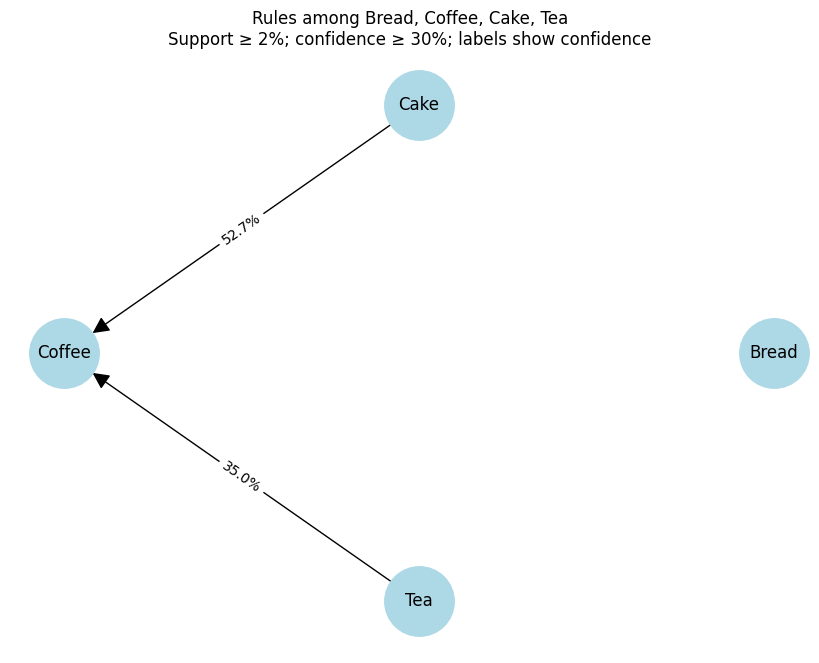

In [17]:
# Rule subgraph: Bread, Coffee, Cake, Tea
focus = {"Bread", "Coffee", "Cake", "Tea"}

sub = rules[
    rules["antecedents"].apply(lambda s: s.issubset(focus))
    & rules["consequents"].apply(lambda s: s.issubset(focus))
]

G = nx.DiGraph()
G.add_nodes_from(sorted(focus))

for _, row in sub.iterrows():
    source = ", ".join(sorted(row["antecedents"]))
    target = ", ".join(sorted(row["consequents"]))
    G.add_edge(source, target, confidence=row["confidence"])

plt.figure(figsize=(8, 6))
pos = nx.circular_layout(G)

nx.draw(
    G, pos, with_labels=True,
    node_color="lightblue", node_size=2500,
    font_size=12, arrows=True, arrowsize=25
)

labels = {
    (a, b): f'{data["confidence"]:.1%}'
    for a, b, data in G.edges(data=True)
}
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.title("Rules among Bread, Coffee, Cake, Tea\n"
          "Support ≥ 2%; confidence ≥ 30%; labels show confidence")
plt.tight_layout()
plt.show()

In [18]:
# Calculate the specific rule required by the interpretation prompt
coffee_cake = basket["Coffee"] & basket["Cake"]
all_three = coffee_cake & basket["Bread"]

support = all_three.mean()
confidence = all_three.sum() / coffee_cake.sum()
lift = confidence / basket["Bread"].mean()

print("Transactions with all three:", all_three.sum())
print("Transactions with Coffee and Cake:", coffee_cake.sum())
print(f"Support: {support:.4f} ({support:.2%})")
print(f"Confidence: {confidence:.4f} ({confidence:.2%})")
print(f"Lift: {lift:.4f}")

Transactions with all three: 95
Transactions with Coffee and Cake: 518
Support: 0.0100 (1.00%)
Confidence: 0.1834 (18.34%)
Lift: 0.5605


## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

The rule {Coffee, Cake} ⇒ {Bread} has a support of approximately 1.00%. This implies that 95 out of the 9,465 baskets purchased all three of these items. The confidence is 18.34%. Out of the 518 baskets that purchased both Coffee and Cake, 95 also purchased Bread. The lift is 0.5605 which implies a negative relationship between these items. If the lift was above 1 there would be a positive relationship. This does not imply causation and is not a great indication that Bread should be recommended to customers who purchased Coffee and Cake. This rule is not included in the results because it does not meet the minimum requirements of 2% support and 30% confidence.

>